In [3]:
#class imbalance >> when one class has higher percentage
#handle class imbalance problem.
'''to handle this we have 3 types
1.upsamping/oversampling
2.downsampling/undersampling
3.SMOTE (synthetic minority oversampling technique)'''


'to handle this we have 3 types\n1.upsamping/oversampling\n2.downsampling/undersampling\n3.SMOTE (synthetic minority oversampling technique)'

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(1) #it will regenerate the same data point again (seed will not generate random number it only generate once)

no_sample = 1000
class_0_ratio = 0.9
class_1_ratio = 0.1
no_class_0= int(no_sample* class_0_ratio)
no_class_1 = int(no_sample * class_1_ratio)


In [5]:
no_class_0, no_class_1

(900, 100)

In [6]:
class_0 = {'Feature1':np.random.normal(0,1,no_class_0),
           'Feature2':np.random.normal(0,1,no_class_0),
           'Target':[0]*no_class_0}#here we get mean of dataset 0, std=1 and 900data points
#np.random.normal(mean,std,number_of_points)
class_0_df = pd.DataFrame(class_0)
class_0_df

,Feature1,Feature2,Target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [7]:
class_1 = {'Feature1':np.random.normal(0,1,no_class_1),
           'Feature2':np.random.normal(0,1,no_class_1),
           'Target':[1]*no_class_1}
class_1_df = pd.DataFrame(class_1)
class_1_df

,Feature1,Feature2,Target
0,-1.307971,0.933630,1
1,1.472396,-1.763775,1
2,0.074876,-0.410217,1
3,-1.786935,-0.453667,1
4,0.165211,-0.589430,1
...,...,...,...
95,0.213026,0.188583,1
96,-0.804542,0.560918,1
97,-0.646582,-0.921659,1
98,1.138173,0.647375,1


In [8]:
df = pd.concat([class_0_df,class_1_df]).reset_index(drop=True)
df

,Feature1,Feature2,Target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
995,0.213026,0.188583,1
996,-0.804542,0.560918,1
997,-0.646582,-0.921659,1
998,1.138173,0.647375,1


In [9]:
df.Target.value_counts()

Target
0    900
1    100
Name: count, dtype: int64

In [10]:
#upsampling (making minority class to similar as majority)
df_minority = df[df['Target']==1]
df_majority = df[df['Target']==0]


In [11]:
#to making or apply sampling technique we have a library called scikit learn
from sklearn.utils import resample


In [12]:
#replace= true (With replacement) (means once a picked sample may repeatedly pick)
df_minority_upsample = resample(df_minority,replace=True, n_samples=len(df_majority),random_state=1) 
#replace = true (means with replacement (allowed to pic again the same)) (flase means not allowed)
#n_samples tells how many datapoints we need for upsampling, random_sate = we can give any number which makes to reproduce same things again and again.
df_minority_upsample

,Feature1,Feature2,Target
937,-0.746224,-1.318523,1
912,-0.551680,-0.101381,1
972,-0.458302,-0.299153,1
909,-1.275114,-1.251957,1
975,-0.572026,1.613562,1
...,...,...,...
936,1.093307,-0.626457,1
998,1.138173,0.647375,1
901,1.472396,-1.763775,1
932,-1.034463,1.084419,1


In [13]:
df_minority_upsample.head()

,Feature1,Feature2,Target
937,-0.746224,-1.318523,1
912,-0.551680,-0.101381,1
972,-0.458302,-0.299153,1
909,-1.275114,-1.251957,1
975,-0.572026,1.613562,1


In [14]:
df_upsampled = pd.concat([df_minority_upsample,df_majority]).reset_index(drop=True)
df_upsampled

,Feature1,Feature2,Target
0,-0.746224,-1.318523,1
1,-0.551680,-0.101381,1
2,-0.458302,-0.299153,1
3,-1.275114,-1.251957,1
4,-0.572026,1.613562,1
...,...,...,...
1795,0.578464,0.833679,0
1796,-0.961264,2.160456,0
1797,-1.458324,1.998992,0
1798,0.494342,0.764041,0


In [15]:
df_upsampled['Target'].value_counts()

Target
1    900
0    900
Name: count, dtype: int64

In [16]:
#downsampling
df_majority_downsample =resample(df_majority,replace=False,n_samples=len(df_minority),random_state=1)
df_majority_downsample

,Feature1,Feature2,Target
860,-0.977773,0.872579,0
880,0.309817,1.835870,0
874,0.050317,0.146532,0
780,0.677808,-0.859827,0
525,0.713049,0.320971,0
...,...,...,...
494,-1.579156,2.711950,0
255,-1.044589,0.522655,0
672,0.410266,0.683356,0
481,-1.114871,-0.800787,0


In [17]:
df_downsample = pd.concat([df_majority_downsample,df_minority]).reset_index(drop=True)
df_downsample

,Feature1,Feature2,Target
0,-0.977773,0.872579,0
1,0.309817,1.835870,0
2,0.050317,0.146532,0
3,0.677808,-0.859827,0
4,0.713049,0.320971,0
...,...,...,...
195,0.213026,0.188583,1
196,-0.804542,0.560918,1
197,-0.646582,-0.921659,1
198,1.138173,0.647375,1


In [18]:
df_downsample['Target'].value_counts()

Target
0    100
1    100
Name: count, dtype: int64

In [19]:
#SMOTE >> synthetic minority oversampling technique
#first take dataset
from sklearn.datasets import make_classification


In [22]:
x,y = make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1, weights=[0.90], random_state=1)
'''(parameter) n_redundant: Int
n_redundant : int, default=2
The number of redundant features. These features are generated as random linear combinations of the informative features.'''

'(parameter) n_redundant: Int\nn_redundant : int, default=2\nThe number of redundant features. These features are generated as random linear combinations of the informative features.'

In [23]:
x

array([[ 1.53682958, -1.39869399],
       [ 1.55110839,  1.81032905],
       [ 1.29361936,  1.01094607],
       ...,
       [-0.55662536, -0.15983725],
       [ 1.00499902,  0.93628981],
       [ 1.46210987,  1.14497791]])

In [24]:
y

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [27]:
len(y[y==0])

894

In [30]:
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['Target'])
final_df = pd.concat([df1,df2],axis=1)
final_df

,f1,f2,Target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
995,2.210439,2.006772,0
996,1.910941,2.011860,0
997,-0.556625,-0.159837,0
998,1.004999,0.936290,0


In [33]:
final_df['Target'].value_counts()

Target
0    894
1    106
Name: count, dtype: int64

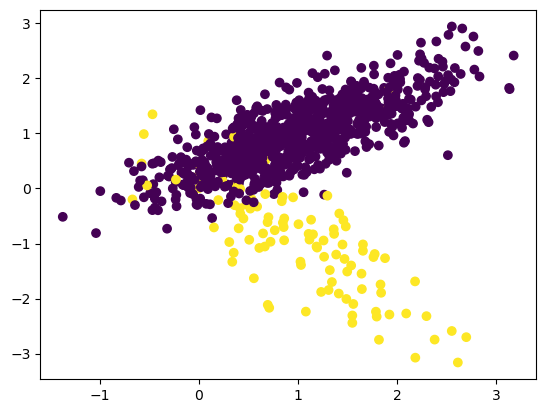

In [34]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['Target'])

In [35]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [36]:
from imblearn.over_sampling import SMOTE


In [37]:
oversample = SMOTE()

In [46]:
x,y = oversample.fit_resample(final_df[['f1','f2']],final_df['Target'])


In [39]:
x.shape

(1788, 2)

In [40]:
y.shape

(1788,)

In [43]:
len(y[y==0]), len(y[y==1])

(894, 894)

In [44]:
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['Target'])
oversample_df = pd.concat([df1,df2],axis=1)
oversample_df

,f1,f2,Target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
1783,0.379066,0.905933,1
1784,1.756310,-2.345462,1
1785,2.334889,-2.820627,1
1786,1.104103,-0.147551,1


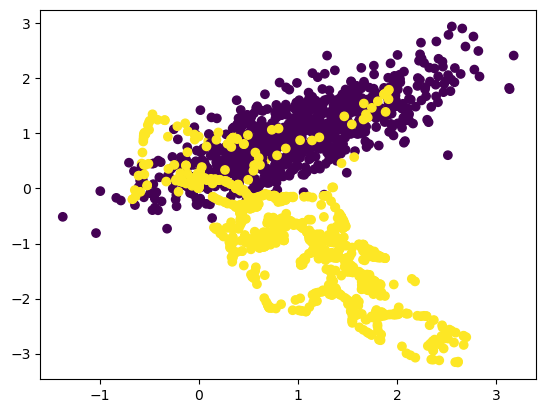

In [45]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['Target'])